<a href="https://colab.research.google.com/github/Kush-Singh-26/NLP/blob/main/Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from torch.utils.data import DataLoader
import torch.optim as optim

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [16]:
class Encoder(nn.Module):

  def __init__(self, input_size, hidden_size, num_layers=1, dropout=0):
    super(Encoder, self).__init__()
    self.num_layers = num_layers
    self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=dropout)

  def forward(self, x, mask, lengths):
    packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
    output, final = self.rnn(packed)
    output, _ = pad_packed_sequence(output, batch_first=True)
    fwd_final = final[0:final.size(0):2]; bwd_final = final[1:final.size(0):2]
    final = torch.cat([fwd_final, bwd_final], dim=2)
    return output, final

In [17]:
class Decoder(nn.Module):

  def __init__(self, emb_size, hidden_size, attention, num_layers=1, dropout=0.5, bridge=True):
    super(Decoder, self).__init__()
    self.hidden_size, self.num_layers, self.attention, self.dropout = hidden_size, num_layers, attention, dropout
    self.rnn = nn.GRU(emb_size + 2 * hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
    self.bridge = nn.Linear(2 * hidden_size, hidden_size, bias=True) if bridge else None
    self.dropout_layer = nn.Dropout(p=dropout)
    self.pre_output_layer = nn.Linear(hidden_size + 2 * hidden_size + emb_size, hidden_size, bias=False)

  def forward_step(self, prev_embed, encoder_hidden, src_mask, proj_key, hidden):
    query = hidden[-1].unsqueeze(1)
    context, _ = self.attention(query=query, proj_key=proj_key, value=encoder_hidden, mask=src_mask)
    rnn_input = torch.cat([prev_embed, context], dim=2)
    output, hidden = self.rnn(rnn_input, hidden)
    pre_output = torch.cat([prev_embed, output, context], dim=2)
    pre_output = self.dropout_layer(pre_output); pre_output = self.pre_output_layer(pre_output)
    return output, hidden, pre_output

  def forward(self, trg_embed, encoder_hidden, encoder_final, src_mask, trg_mask=None, hidden=None, max_len=None):
    if max_len is None: max_len = trg_embed.size(1)
    if hidden is None: hidden = self.init_hidden(encoder_final)
    proj_key = self.attention.key_layer(encoder_hidden)
    pre_output_vectors = []
    for i in range(max_len):
        prev_embed = trg_embed[:, i].unsqueeze(1)
        _, hidden, pre_output = self.forward_step(prev_embed, encoder_hidden, src_mask, proj_key, hidden)
        pre_output_vectors.append(pre_output)
    pre_output_vectors = torch.cat(pre_output_vectors, dim=1)
    return pre_output_vectors, hidden, None

  def init_hidden(self, encoder_final):
    if encoder_final is None: return None
    return torch.tanh(self.bridge(encoder_final)) if self.bridge else encoder_final

In [18]:
class BahdanauAttention(nn.Module):

  def __init__(self, hidden_size, key_size=None, query_size=None):
    super(BahdanauAttention, self).__init__()
    key_size = 2 * hidden_size if key_size is None else key_size
    query_size = hidden_size if query_size is None else query_size
    self.key_layer = nn.Linear(key_size, hidden_size, bias=False)
    self.query_layer = nn.Linear(query_size, hidden_size, bias=False)
    self.energy_layer = nn.Linear(hidden_size, 1, bias=False)
    self.alphas=None

  def forward(self, query=None, proj_key=None, value=None, mask=None):
    assert mask is not None, "mask required"
    query = self.query_layer(query)
    scores = self.energy_layer(torch.tanh(query + proj_key)).squeeze(2).unsqueeze(1)
    scores.masked_fill_(mask == 0, -1e9)
    alphas = F.softmax(scores, dim=-1)
    self.alphas = alphas
    context = torch.bmm(alphas, value)
    return context, alphas

In [19]:
class EncoderDecoder(nn.Module):

  def __init__(self, encoder, decoder, src_embed, trg_embed, generator):
    super(EncoderDecoder, self).__init__()
    self.encoder, self.decoder, self.src_embed, self.trg_embed, self.generator = encoder, decoder, src_embed, trg_embed, generator

  def forward(self, src, trg, src_mask, trg_mask, src_lengths):
    encoder_hidden, encoder_final = self.encode(src, src_mask, src_lengths)
    return self.decode(encoder_hidden, encoder_final, src_mask, trg, trg_mask)

  def encode(self, src, src_mask, src_lengths):
    return self.encoder(self.src_embed(src), src_mask, src_lengths)

  def decode(self, encoder_hidden, encoder_final, src_mask, trg, trg_mask, decoder_hidden=None):
    return self.decoder(self.trg_embed(trg), encoder_hidden, encoder_final, src_mask, trg_mask, hidden=decoder_hidden)

In [20]:
class Generator(nn.Module):

  def __init__(self, hidden_size, vocab_size):
    super(Generator, self).__init__()
    self.proj = nn.Linear(hidden_size, vocab_size, bias=False)

  def forward(self, x): return F.log_softmax(self.proj(x), dim=-1)

In [21]:
def make_model(src_vocab_size, tgt_vocab_size, emb_size=256, hidden_size=512, num_layers=1, dropout=0.1):

  attention = BahdanauAttention(hidden_size)
  model = EncoderDecoder(
      Encoder(emb_size, hidden_size, num_layers=num_layers, dropout=dropout),
      Decoder(emb_size, hidden_size, attention, num_layers=num_layers, dropout=dropout),
      nn.Embedding(src_vocab_size, emb_size), nn.Embedding(tgt_vocab_size, emb_size),
      Generator(hidden_size, tgt_vocab_size)
  )

  for p in model.parameters():
    if p.dim() > 1: nn.init.xavier_uniform_(p)
  return model.to(device)

In [22]:
! python -m spacy download en_core_web_sm
! python -m spacy download de_core_news_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
  Using cached https://github.com/explosion/spacy-models/releases/download/de_core_news_sm-3.8.0/de_core_news_sm-3.8.0-py3-none-any.whl (14.6 MB)
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [23]:
! pip install jsonlines

In [24]:
import jsonlines
from datasets import Dataset, DatasetDict

def load_jsonl(file_path):
    data = []
    with jsonlines.open(file_path) as reader:
        for obj in reader:
            data.append(obj)
    return Dataset.from_list(data)

# Load each split
train_dataset = load_jsonl("data/train.jsonl")
val_dataset = load_jsonl("data/val.jsonl")
test_dataset = load_jsonl("data/test.jsonl")

# Combine into a DatasetDict
full_dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})


In [25]:
train_dataset[0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

In [26]:
import spacy

In [27]:
spacy_en = spacy.load("en_core_web_sm")
spacy_de = spacy.load("de_core_news_sm")
def tokenize_de(text): return [tok.text for tok in spacy_de.tokenizer(text)]
def tokenize_en(text): return [tok.text for tok in spacy_en.tokenizer(text)]

In [28]:
from collections import Counter

In [29]:
class Vocabulary:
    def __init__(self, tokenizer, specials=['<unk>', '<pad>', '<sos>', '<eos>']):
        self.tokenizer, self.specials = tokenizer, specials
        self.stoi, self.itos = {}, {}

    def build_vocab(self, sentence_iterator):
        word_counts = Counter(tok for sent in sentence_iterator for tok in self.tokenizer(sent))
        for i, special in enumerate(self.specials): self.stoi[special] = i
        idx = len(self.specials)
        for word, count in word_counts.items():
            self.stoi[word] = idx
            idx += 1
        self.itos = {i: s for s, i in self.stoi.items()}

    def numericalize(self, text):
        tokens = self.tokenizer(text)
        return [self.stoi.get(token, self.stoi['<unk>']) for token in tokens]

    def __len__(self): return len(self.stoi)


In [30]:
src_vocab = Vocabulary(tokenize_en)
trg_vocab = Vocabulary(tokenize_de)

# Create iterators from the 'train' split to build vocab
src_sentence_iterator = (example['en'] for example in full_dataset['train'])
trg_sentence_iterator = (example['de'] for example in full_dataset['train'])

src_vocab.build_vocab(src_sentence_iterator)
trg_vocab.build_vocab(trg_sentence_iterator)
print(f"Source vocab size: {len(src_vocab)}")
print(f"Target vocab size: {len(trg_vocab)}")

Source vocab size: 10837
Target vocab size: 19214


In [31]:
def tokenize_and_numericalize(example):
    # The 'example' here is a dictionary from your dataset, e.g., {'translation': ...}
    src_text = example['en']
    trg_text = example['de']

    src_ids = [src_vocab.stoi['<sos>']] + src_vocab.numericalize(src_text) + [src_vocab.stoi['<eos>']]
    trg_ids = [trg_vocab.stoi['<sos>']] + trg_vocab.numericalize(trg_text) + [trg_vocab.stoi['<eos>']]

    return {'src_ids': src_ids, 'trg_ids': trg_ids}

tokenized_datasets = full_dataset.map(tokenize_and_numericalize)
print(tokenized_datasets)

# tokenized_datasets.set_format(type='torch', columns=['src_ids', 'trg_ids'])

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['en', 'de', 'src_ids', 'trg_ids'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de', 'src_ids', 'trg_ids'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de', 'src_ids', 'trg_ids'],
        num_rows: 1000
    })
})


In [32]:
def collate_fn_new(batch, pad_index):
    # 'batch' is now a list of dictionaries: [{'src_ids': tensor, 'trg_ids': tensor}, ...]
    src_list = []
    trg_list = []

    for item in batch:
        src_list.append(torch.LongTensor(item['src_ids']))
        trg_list.append(torch.LongTensor(item['trg_ids']))

    src_lengths = torch.tensor([len(s) for s in src_list])
    trg_lengths = torch.tensor([len(t) for t in trg_list])

    src_padded = pad_sequence(src_list, batch_first=True, padding_value=pad_index)
    trg_padded = pad_sequence(trg_list, batch_first=True, padding_value=pad_index)

    return (src_padded, src_lengths), (trg_padded, trg_lengths)


In [33]:
class Batch:
    def __init__(self, src, trg, pad_index=0, device=None):
        src, src_lengths = src
        self.src = src.to(device)
        self.src_lengths = src_lengths.to(device)
        self.src_mask = (self.src != pad_index).unsqueeze(1).to(device)
        self.nseqs = self.src.size(0)
        if trg is not None:
            trg, _ = trg
            self.trg = trg[:, :-1].to(device)
            self.trg_y = trg[:, 1:].to(device)
            self.trg_mask = (self.trg_y != pad_index)
            self.ntokens = self.trg_mask.sum().item()

In [34]:
def train_epoch(model, dataloader, optimizer, criterion, clip, pad_idx, print_every=100):
    model.train()
    total_epoch_loss = 0
    start_time = time.time()
    running_loss = 0
    for i, (src_data, trg_data) in enumerate(dataloader):
        batch = Batch(src_data, trg_data, pad_index=pad_idx, device=device)

        optimizer.zero_grad()

        output, _, _ = model(batch.src, batch.trg, batch.src_mask, batch.trg_mask, batch.src_lengths)
        log_probs = model.generator(output)

        loss = criterion(log_probs.reshape(-1, log_probs.size(-1)), batch.trg_y.reshape(-1))

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        # Accumulate loss for the entire epoch and for the logging window
        total_epoch_loss += loss.item()
        running_loss += loss.item()

        # --- Logging block ---
        # We use (i + 1) because i is 0-indexed.
        if (i + 1) % print_every == 0:
            avg_loss = running_loss / print_every
            ppl = math.exp(avg_loss) if avg_loss < 100 else float('inf')

            # Calculate batches per second
            end_time = time.time()
            elapsed_time = end_time - start_time
            batches_per_sec = print_every / elapsed_time

            print(f'  Batch {i+1:>5}/{len(dataloader):<5} | Avg Loss (last {print_every}): {avg_loss:.4f} | '
                  f'PPL: {ppl:7.2f} | BPS: {batches_per_sec:.2f}')

            # Reset for the next logging window
            running_loss = 0
            start_time = time.time()

    # Return the average loss for the whole epoch
    return total_epoch_loss / len(dataloader)


def evaluate(model, dataloader, criterion, pad_idx):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src_data, trg_data in dataloader:
            batch = Batch(src_data, trg_data, pad_index=pad_idx, device=device)
            output, _, _ = model(batch.src, batch.trg, batch.src_mask, batch.trg_mask, batch.src_lengths)
            log_probs = model.generator(output)
            loss = criterion(log_probs.view(-1, log_probs.size(-1)), batch.trg_y.reshape(-1))
            epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

In [35]:
def translate_sentence(sentence, model, src_vocab, trg_vocab, max_len=50):
    model.eval()
    tokens = [src_vocab.stoi['<sos>']] + src_vocab.numericalize(sentence) + [src_vocab.stoi['<eos>']]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)
    src_mask = (src_tensor != src_vocab.stoi['<pad>']).unsqueeze(1).to(device)
    src_lengths = torch.LongTensor([len(tokens)]).to('cpu')
    with torch.no_grad():
        encoder_hidden, encoder_final = model.encode(src_tensor, src_mask, src_lengths)
        proj_key = model.decoder.attention.key_layer(encoder_hidden)
    decoder_hidden = model.decoder.init_hidden(encoder_final)
    trg_indexes = [trg_vocab.stoi['<sos>']]
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).unsqueeze(0).to(device)
        with torch.no_grad():
            prev_embed = model.trg_embed(trg_tensor)
            _, decoder_hidden, pre_output = model.decoder.forward_step(
                prev_embed, encoder_hidden, src_mask, proj_key, decoder_hidden
            )
            log_probs = model.generator(pre_output)
            pred_token = log_probs.squeeze(1).argmax(dim=-1).item()
        trg_indexes.append(pred_token)
        if pred_token == trg_vocab.stoi['<eos>']: break
    trg_tokens = [trg_vocab.itos[i] for i in trg_indexes]
    return " ".join(trg_tokens[1:-1])

In [36]:
from functools import partial

In [37]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [38]:
N_EPOCHS = 50
LEARNING_RATE = 0.0005
EMB_SIZE = 256
HIDDEN_SIZE = 256
NUM_LAYERS = 1
DROPOUT = 0.65
CLIP = 1
BATCH_SIZE = 64
PRINT_EVERY=50

PAD_IDX = src_vocab.stoi['<pad>']
SRC_VOCAB_SIZE = len(src_vocab)
TGT_VOCAB_SIZE = len(trg_vocab)

collate_with_pad = partial(collate_fn_new, pad_index=PAD_IDX)
train_dataloader = DataLoader(tokenized_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_with_pad)
val_dataloader = DataLoader(tokenized_datasets['validation'], batch_size=BATCH_SIZE, collate_fn=collate_with_pad)

model = make_model(SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, emb_size=EMB_SIZE, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5, verbose=True)
criterion = nn.NLLLoss(ignore_index=PAD_IDX)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.65 and num_layers=1
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [39]:
import time as time
import math

In [40]:
best_valid_loss = float('inf')
for epoch in range(N_EPOCHS):
    start_time = time.time()
    train_loss = train_epoch(model, train_dataloader, optimizer, criterion, CLIP, PAD_IDX, print_every=PRINT_EVERY)
    valid_loss = evaluate(model, val_dataloader, criterion, PAD_IDX)
    scheduler.step(valid_loss)
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'nmt-model.pt')

    print(f'End of Epoch: {epoch+1:02} | Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tEpoch Train Loss: {train_loss:.3f} | Epoch Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\tEpoch Val. Loss: {valid_loss:.3f} |  Epoch Val. PPL: {math.exp(valid_loss):7.3f}')

  Batch    50/454   | Avg Loss (last 50): 7.2301 | PPL: 1380.31 | BPS: 10.96
  Batch   100/454   | Avg Loss (last 50): 5.5922 | PPL:  268.32 | BPS: 14.65
  Batch   150/454   | Avg Loss (last 50): 5.1692 | PPL:  175.77 | BPS: 12.25
  Batch   200/454   | Avg Loss (last 50): 4.8678 | PPL:  130.03 | BPS: 14.29
  Batch   250/454   | Avg Loss (last 50): 4.6279 | PPL:  102.30 | BPS: 14.33
  Batch   300/454   | Avg Loss (last 50): 4.4707 | PPL:   87.42 | BPS: 13.25
  Batch   350/454   | Avg Loss (last 50): 4.3568 | PPL:   78.01 | BPS: 12.79
  Batch   400/454   | Avg Loss (last 50): 4.2107 | PPL:   67.40 | BPS: 14.01
  Batch   450/454   | Avg Loss (last 50): 4.1173 | PPL:   61.39 | BPS: 14.24
End of Epoch: 01 | Time: 0m 34s
	Epoch Train Loss: 4.953 | Epoch Train PPL: 141.592
	Epoch Val. Loss: 4.065 |  Epoch Val. PPL:  58.264
  Batch    50/454   | Avg Loss (last 50): 3.9136 | PPL:   50.08 | BPS: 13.00
  Batch   100/454   | Avg Loss (last 50): 3.8610 | PPL:   47.52 | BPS: 13.82
  Batch   150/454 

In [50]:
import torch
import torch.nn.functional as F

def beam_search_decode(model, src_tensor, src_mask, src_lengths, src_vocab, trg_vocab, beam_size=5, max_len=50, length_penalty=0.7):
    """
    Performs beam search decoding on a single sentence.

    Args:
        model: The trained EncoderDecoder model.
        src_tensor: A tensor of the source sentence IDs, shape (1, src_len).
        src_mask: The source mask tensor.
        src_lengths: The source lengths tensor.
        src_vocab: The source vocabulary object.
        trg_vocab: The target vocabulary object.
        beam_size (int): The number of hypotheses to keep at each step.
        max_len (int): The maximum length for the generated translation.
        length_penalty (float): Alpha factor for length normalization. 0=no penalty.

    Returns:
        A string representing the translated sentence.
    """
    model.eval()

    sos_idx = trg_vocab.stoi['<sos>']
    eos_idx = trg_vocab.stoi['<eos>']

    with torch.no_grad():
        # 1. Encode the source sentence once
        encoder_hidden, encoder_final = model.encode(src_tensor, src_mask, src_lengths)
        proj_key = model.decoder.attention.key_layer(encoder_hidden)
        decoder_hidden = model.decoder.init_hidden(encoder_final)

        # 2. Initialize the beam
        # Each beam contains: (cumulative_log_prob, sequence_tensor, decoder_hidden_state)
        beams = [(0.0, torch.LongTensor([sos_idx]).to(device), decoder_hidden)]
        completed_hypotheses = []

        for _ in range(max_len):
            if not beams:
                break # All beams have finished

            all_candidates = []

            # 3. Expand each beam
            for score, seq, hidden in beams:
                # Get the last token of the current sequence
                last_token = seq[-1].unsqueeze(0).unsqueeze(0)

                # Run one step of the decoder
                prev_embed = model.trg_embed(last_token)
                _, new_hidden, pre_output = model.decoder.forward_step(
                    prev_embed, encoder_hidden, src_mask, proj_key, hidden)

                # Get log probabilities for the next word
                log_probs = model.generator(pre_output).squeeze(1)

                # 4. Get top-k next tokens and their log-probs
                top_k_log_probs, top_k_indices = torch.topk(log_probs, beam_size, dim=-1)

                for i in range(beam_size):
                    next_token_idx = top_k_indices[0, i].item()
                    token_log_prob = top_k_log_probs[0, i].item()

                    new_score = score + token_log_prob
                    new_seq = torch.cat([seq, torch.LongTensor([next_token_idx]).to(device)])

                    all_candidates.append((new_score, new_seq, new_hidden))

            # 5. Prune the beams
            # Sort all candidates by their score
            all_candidates.sort(key=lambda x: x[0], reverse=True)

            # Reset the beams list for the next time step
            beams = []

            for new_score, new_seq, new_hidden in all_candidates:
                # If a hypothesis ends in <eos>, it's complete.
                if new_seq[-1].item() == eos_idx:
                    # Apply length penalty and add to completed list
                    # score / (length^alpha)
                    final_score = new_score / (len(new_seq) ** length_penalty)
                    completed_hypotheses.append((final_score, new_seq))
                else:
                    # This is still an active beam, add it to the list for the next step
                    beams.append((new_score, new_seq, new_hidden))

                # We only need to keep `beam_size` total hypotheses (both active and completed)
                if len(beams) + len(completed_hypotheses) >= beam_size:
                    break

            # To ensure we don't just keep expanding the same top beam, we only keep `beam_size` active beams
            beams = beams[:beam_size]

        # 6. Select the best hypothesis
        # If no hypothesis completed, use the best one from the active beams
        if not completed_hypotheses:
            # Fallback to the best active beam
            if beams:
                best_score, best_seq, _ = beams[0]
                completed_hypotheses.append((best_score/len(best_seq)**length_penalty, best_seq))
            else:
                return "" # Return empty if no translation could be generated

    # Sort all completed hypotheses by their normalized score
    completed_hypotheses.sort(key=lambda x: x[0], reverse=True)

    # Get the sequence of the best hypothesis
    best_seq = completed_hypotheses[0][1]

    # Convert token IDs to words
    trg_tokens = [trg_vocab.itos[idx.item()] for idx in best_seq]

    # Return translation, excluding <sos> and <eos>
    return " ".join(trg_tokens[1:-1] if trg_tokens[-1] == '<eos>' else trg_tokens[1:])

In [61]:
def translate_sentence_greedy(sentence, model, src_vocab, trg_vocab, max_len=50):
    model.eval()
    tokens = [src_vocab.stoi['<sos>']] + src_vocab.numericalize(sentence) + [src_vocab.stoi['<eos>']]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)
    src_mask = (src_tensor != src_vocab.stoi['<pad>']).unsqueeze(1).to(device)
    src_lengths = torch.LongTensor([len(tokens)]).to('cpu')
    with torch.no_grad():
        encoder_hidden, encoder_final = model.encode(src_tensor, src_mask, src_lengths)
        proj_key = model.decoder.attention.key_layer(encoder_hidden)
    decoder_hidden = model.decoder.init_hidden(encoder_final)
    trg_indexes = [trg_vocab.stoi['<sos>']]
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).unsqueeze(0).to(device)
        with torch.no_grad():
            prev_embed = model.trg_embed(trg_tensor)
            _, decoder_hidden, pre_output = model.decoder.forward_step(
                prev_embed, encoder_hidden, src_mask, proj_key, decoder_hidden
            )
            log_probs = model.generator(pre_output)
            pred_token = log_probs.squeeze(1).argmax(dim=-1).item()
        trg_indexes.append(pred_token)
        if pred_token == trg_vocab.stoi['<eos>']: break
    trg_tokens = [trg_vocab.itos[i] for i in trg_indexes]
    return " ".join(trg_tokens[1:-1] if trg_tokens and trg_tokens[-1] == '<eos>' else trg_tokens[1:])


def translate_sentence_beam(sentence, model, src_vocab, trg_vocab, beam_size=5, max_len=50):
    model.eval()
    tokens = [src_vocab.stoi['<sos>']] + src_vocab.numericalize(sentence) + [src_vocab.stoi['<eos>']]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)
    src_mask = (src_tensor != src_vocab.stoi['<pad>']).unsqueeze(1).to(device)
    src_lengths = torch.LongTensor([len(tokens)]).to('cpu')
    translation = beam_search_decode(model, src_tensor, src_mask, src_lengths, src_vocab, trg_vocab, beam_size, max_len)
    return translation

model.load_state_dict(torch.load('nmt-model.pt'))

test_sentence = "A man is swimming in ocean"

print(f"Source: \t{test_sentence}")
print("-" * 30)

greedy_translation = translate_sentence_greedy(test_sentence, model, src_vocab, trg_vocab)
print(f"Greedy Translation: \t{greedy_translation}")

beam_translation = translate_sentence_beam(test_sentence, model, src_vocab, trg_vocab, beam_size=5)
print(f"Beam Search (k=5): \t{beam_translation}")

Source: 	A man is swimming in ocean
------------------------------
Greedy Translation: 	Ein Mann schwimmt im Meer .
Beam Search (k=5): 	Ein Mann schwimmt im Meer .


In [52]:
!pip install -q sacrebleu

In [53]:
# New cell for BLEU calculation using sacrebleu

# Make sure you have run !pip install sacrebleu
import sacrebleu
import tqdm # Using tqdm to show a progress bar, which is nice for larger datasets

def calculate_bleu_sacrebleu(dataset, model, src_vocab, trg_vocab, max_len=50):
    """
    Calculates BLEU score using the sacrebleu library.
    """

    # Isolate the target sentences from the dataset
    # sacrebleu expects a list of reference sentences.
    # The required format is: [[ref1_sent1, ref2_sent1, ...], [ref1_sent2, ...], ...]
    # For our case, we only have one reference per source, so it's: [[ref_sent1], [ref_sent2], ...]
    references = [[example['de']] for example in dataset]

    # Generate predictions for all source sentences
    hypotheses = []
    for example in tqdm.tqdm(dataset, desc="Translating for BLEU"):
        src_sentence = example['en']
        prediction = translate_sentence(src_sentence, model, src_vocab, trg_vocab, max_len)
        hypotheses.append(prediction)

    # Calculate and return the BLEU score
    # force=True allows it to overwrite a cache file if it exists
    # The .score attribute gives you the score on a 0-100 scale.
    bleu = sacrebleu.corpus_bleu(hypotheses, references, force=True)
    return bleu.score

# --- Load your best model and run the new BLEU calculation ---
# Make sure your best model is loaded
model.load_state_dict(torch.load('nmt-model.pt'))

# Use the validation set (or test set) to calculate BLEU
# Using a subset is fine for a quick check, e.g., list(dataset)[:500]
print("\nCalculating BLEU score on validation set...")
bleu_score = calculate_bleu_sacrebleu(full_dataset['validation'], model, src_vocab, trg_vocab)

print(f"SacreBLEU score on validation set = {bleu_score:.2f}")


Calculating BLEU score on validation set...


Translating for BLEU: 100%|██████████| 1014/1014 [00:24<00:00, 41.33it/s]

SacreBLEU score on validation set = 34.57


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [55]:
def translate_and_get_attention(sentence, model, src_vocab, trg_vocab, max_len=50):
    """
    Translates a sentence using greedy decoding and returns the attention weights.
    """
    model.eval()

    # 1. Prepare the source sentence (tokenize, numericalize, add tokens)
    src_tokens_text = ['<sos>'] + src_vocab.tokenizer(sentence) + ['<eos>']
    src_tokens_ids = [src_vocab.stoi[token] for token in src_tokens_text]
    src_tensor = torch.LongTensor(src_tokens_ids).unsqueeze(0).to(device)
    src_mask = (src_tensor != src_vocab.stoi['<pad>']).unsqueeze(1).to(device)
    src_lengths = torch.LongTensor([len(src_tokens_ids)]).to('cpu')

    # 2. Encode the source sentence
    with torch.no_grad():
        encoder_hidden, encoder_final = model.encode(src_tensor, src_mask, src_lengths)
        proj_key = model.decoder.attention.key_layer(encoder_hidden)

    # 3. Initialize the decoder and lists for results
    decoder_hidden = model.decoder.init_hidden(encoder_final)
    trg_indexes = [trg_vocab.stoi['<sos>']]
    attentions = [] # List to store attention tensors

    # 4. Greedy decoding loop
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).unsqueeze(0).to(device)

        with torch.no_grad():
            # Perform one decoding step
            prev_embed = model.trg_embed(trg_tensor)
            _, decoder_hidden, pre_output = model.decoder.forward_step(
                prev_embed, encoder_hidden, src_mask, proj_key, decoder_hidden
            )

            # *** CAPTURE THE ATTENTION WEIGHTS ***
            # The weights are stored in the attention module after its forward pass
            # Shape is (1, 1, src_len), so we squeeze it.
            attention_weights = model.decoder.attention.alphas.squeeze(0).cpu()
            attentions.append(attention_weights)

            # Generate the next predicted token
            log_probs = model.generator(pre_output)
            pred_token = log_probs.squeeze(1).argmax(dim=-1).item()

        trg_indexes.append(pred_token)

        if pred_token == trg_vocab.stoi['<eos>']:
            break

    # Convert target indices to tokens
    trg_tokens_text = [trg_vocab.itos[i] for i in trg_indexes]

    # 5. Combine attention tensors into a single matrix
    # Stack the list of (1, src_len) tensors into a (trg_len, src_len) matrix
    attention_matrix = torch.cat(attentions, dim=0).numpy()

    return trg_tokens_text[1:], src_tokens_text, attention_matrix

In [56]:
# In a new cell

def plot_attention_heatmap(source_tokens, target_tokens, attention_matrix):
    """
    Plots a heatmap of the attention matrix.
    """
    # Ensure target tokens don't include <sos> but do include <eos> if it exists
    # The matrix dimensions should be (len(target_tokens), len(source_tokens))
    target_tokens_for_plot = target_tokens

    fig, ax = plt.subplots(figsize=(8, 10))

    # Use seaborn for a nice-looking heatmap
    sns.heatmap(attention_matrix, xticklabels=source_tokens, yticklabels=target_tokens_for_plot,
                cmap='viridis', ax=ax, cbar=True)

    ax.set_title('Attention Heatmap', fontsize=16)
    ax.set_xlabel('Source Sentence', fontsize=12)
    ax.set_ylabel('Generated Translation', fontsize=12)

    # Rotate the x-axis labels to prevent them from overlapping
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # Make sure layout is tight
    plt.tight_layout()
    plt.show()

Source Sentence: A man in a blue shirt is standing on a ladder and cleaning a window.

Generated Translation: Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt einen Fenster . <eos>


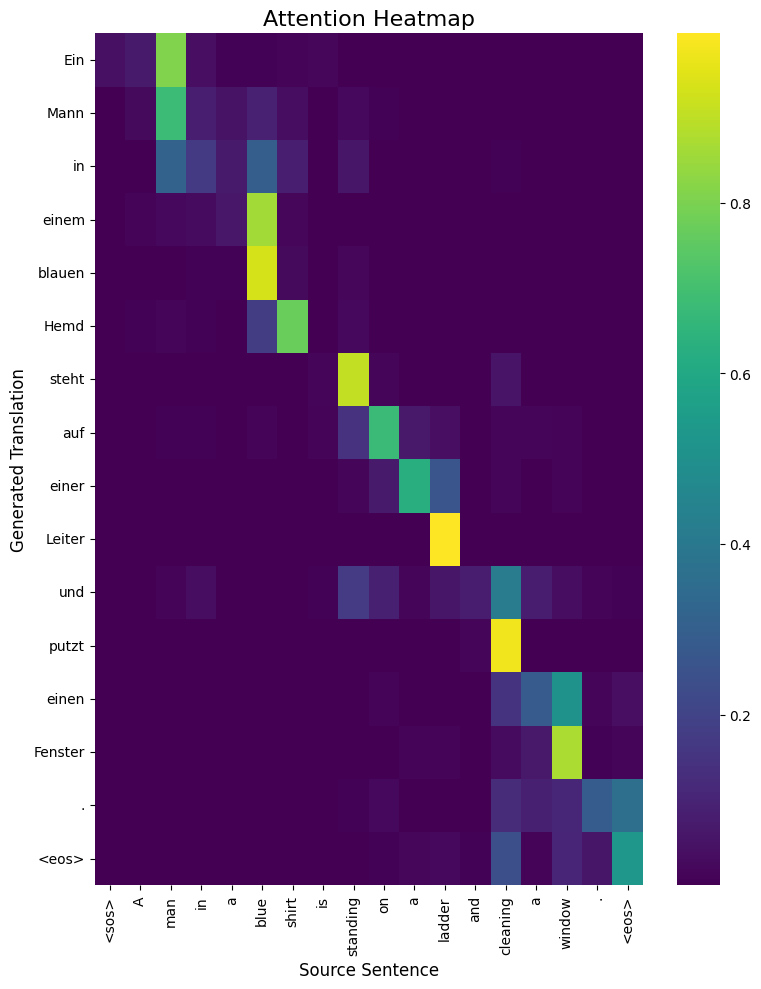

In [59]:
# In a new cell

# --- Load your best model ---
model.load_state_dict(torch.load('nmt-model.pt'))

# --- Choose a sentence to test ---
test_sentence = "A man in a blue shirt is standing on a ladder and cleaning a window."
# Another good one: "Several men in hard hats are operating a giant pulley system."

print(f"Source Sentence: {test_sentence}\n")

# --- Get the translation and attention matrix ---
generated_translation_tokens, source_tokens, attention_matrix = translate_and_get_attention(
    test_sentence, model, src_vocab, trg_vocab
)

print(f"Generated Translation: {' '.join(generated_translation_tokens)}")

# --- Plot the heatmap ---
# We use the generated tokens up to the <eos> token for the y-axis
plot_attention_heatmap(source_tokens, generated_translation_tokens, attention_matrix)